# Water Quality Classification – Original Version (CSV)

This notebook is the **original experiment** that loads data from a local CSV file.
It is kept as reference. The reimplemented version (T2.6) loads data from DBRepo API instead.

**Task:** Classify Lithuanian lake water quality as Good / Moderate / Poor  
**Model:** Random Forest Classifier  
**Dataset:** National Lakes Monitoring Data (Lithuania)

In [1]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "seaborn", "scikit-learn", "matplotlib", "pandas", "numpy", "joblib"], capture_output=False)

print("All libraries installed!")

All libraries installed!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


In [3]:
# ── LOAD FROM LOCAL CSV ────────────────────────────────────────────────────
df = pd.read_csv(r"D:\Lakes_Monitoring.csv")
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 1935 rows, 116 columns


In [4]:
# Drop system columns
df = df.drop(columns=['_type', '_id', '_revision', '_page.next'], errors='ignore')

# Fix detection-limit values (e.g. '<0.05' → 0.025)
def fix_detection_limit(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return value
    val_str = str(value).strip()
    if val_str in ['', '-', 'nan', 'None', 'Nematuota', 'nematuota']:
        return np.nan
    if val_str.startswith('<'):
        try:
            return float(val_str.replace('<', '').replace(',', '.').strip()) / 2
        except:
            return np.nan
    try:
        return float(val_str.replace(',', '.'))
    except:
        return np.nan

numeric_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in numeric_cols:
    df[col] = df[col].apply(fix_detection_limit)

print('Preprocessing done! Shape:', df.shape)

Preprocessing done! Shape: (1935, 112)


In [5]:
def classify_water_quality(row):
    score = 0
    count = 0
    
    ph  = row.get('ph',  np.nan)
    do  = row.get('deguonis_istirpes', np.nan)
    chl = row.get('chlorofilas_a', np.nan)
    bod = row.get('biochem_deg_suvartojimas', np.nan)

    if pd.notna(ph):
        score += 2 if 6.5 <= ph <= 8.5 else (1 if 6.0 <= ph <= 9.0 else 0)
        count += 1
    if pd.notna(do):
        score += 2 if do >= 8 else (1 if do >= 5 else 0)
        count += 1
    if pd.notna(chl):
        score += 2 if chl <= 10 else (1 if chl <= 25 else 0)
        count += 1
    if pd.notna(bod):
        score += 2 if bod <= 3 else (1 if bod <= 6 else 0)
        count += 1

    if count == 0:
        return 'Unknown'
    avg = score / count
    return 'Good' if avg >= 1.5 else ('Moderate' if avg >= 0.8 else 'Poor')

df['quality_class'] = df.apply(classify_water_quality, axis=1)
print('Class distribution:')
print(df['quality_class'].value_counts())

Class distribution:
quality_class
Good        1507
Moderate     379
Poor          48
Unknown        1
Name: count, dtype: int64


In [7]:
# Remove anglingumas and kalcio_karbonatas — only 21 rows each
FEATURE_COLS = [
    'vandens_temp', 'ph', 'deguonis_istirpes', 'elektr_laidis',
    'biochem_deg_suvartojimas', 'skaidrumas', 'chlorofilas_a',
    'nitratu_azotas', 'azotas_bendras', 'fosforas_bendras',
    'sarmingumas'
]
TARGET_COL = 'quality_class'

df_model = df[FEATURE_COLS + [TARGET_COL]].copy()

# Convert all to numeric
for col in FEATURE_COLS:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

df_model = df_model.dropna()
print(f"Rows after dropping NaN: {len(df_model)}")
print()
print("Class distribution:")
print(df_model['quality_class'].value_counts())

Rows after dropping NaN: 1786

Class distribution:
quality_class
Good        1399
Moderate     344
Poor          43
Name: count, dtype: int64


In [8]:
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Classes:', le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Classes: ['Good' 'Moderate' 'Poor']
Train: 1428 | Test: 358


In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [11]:
y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print('=== EVALUATION RESULTS (CSV VERSION) ===')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 Score:  {f1:.4f}')
print()

import numpy as np
present_classes = np.unique(y_test)
present_names   = le.inverse_transform(present_classes)
print(classification_report(y_test, y_pred, labels=present_classes, target_names=present_names))

csv_results = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
print()
print('=== COPY THESE INTO T2.6 CELL 8 ===')
print(f"'accuracy':  {acc:.4f},")
print(f"'precision': {prec:.4f},")
print(f"'recall':    {rec:.4f},")
print(f"'f1':        {f1:.4f},")

=== EVALUATION RESULTS (CSV VERSION) ===
Accuracy:  0.9190
Precision: 0.9090
Recall:    0.9190
F1 Score:  0.9106

              precision    recall  f1-score   support

        Good       0.95      0.98      0.96       280
    Moderate       0.80      0.77      0.79        69
        Poor       0.50      0.11      0.18         9

    accuracy                           0.92       358
   macro avg       0.75      0.62      0.64       358
weighted avg       0.91      0.92      0.91       358


=== COPY THESE INTO T2.6 CELL 8 ===
'accuracy':  0.9190,
'precision': 0.9090,
'recall':    0.9190,
'f1':        0.9106,


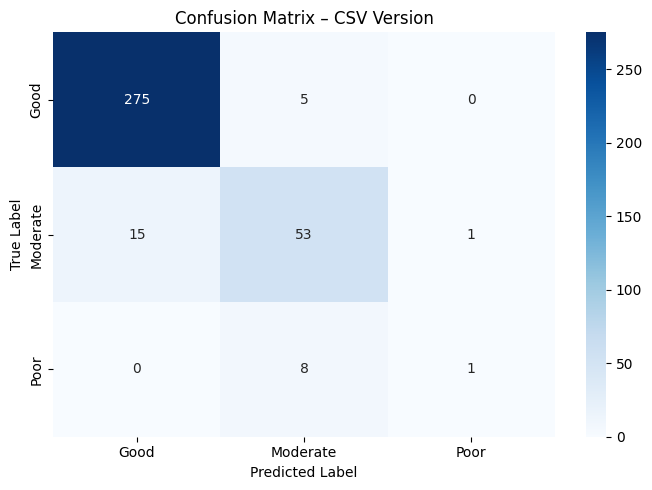

Saved!


In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – CSV Version')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_csv.png', dpi=150)
plt.show()
print('Saved!')

In [14]:
#joblib.dump(model, 'water_quality_model.pkl')
#joblib.dump(le,    'label_encoder.pkl')
#print('Model saved to water_quality_model.pkl')
#print('Label encoder saved to label_encoder.pkl')